In [1]:
import pandas as pd
df = pd.read_csv("Superstore_dataset.csv",encoding='latin1')
df.head()

,Order Date,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,08-11-2016,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,08-11-2016,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,12-06-2016,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,11-10-2015,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,11-10-2015,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [5]:
df.isnull().sum()

Order Date      0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [7]:
df.duplicated().sum()

1

In [9]:
df=df.drop_duplicates()

In [17]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors='coerce')

In [19]:
print(df["Order Date"].head())
print(df["Order Date"].nunique())

0   2016-11-08
1   2016-11-08
2   2016-06-12
3   2015-10-11
4   2015-10-11
Name: Order Date, dtype: datetime64[ns]
1237


In [21]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day

In [23]:
df.to_csv("final_cleaned_data.csv", index=False)

In [25]:
# EDA- Total business overview
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())
print("Total Quantity:", df["Quantity"].sum())

Total Sales: 2296919.4883000003
Total Profit: 286409.0805
Total Quantity: 37871


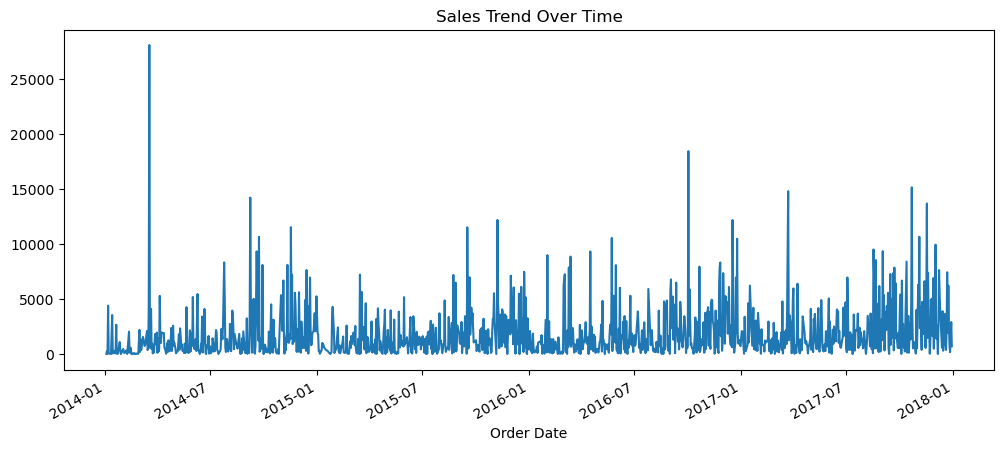

In [27]:
# Sales and growth over time
import matplotlib.pyplot as plt

df.groupby("Order Date")["Sales"].sum().plot(figsize=(12,5))
plt.title("Sales Trend Over Time")
plt.show()

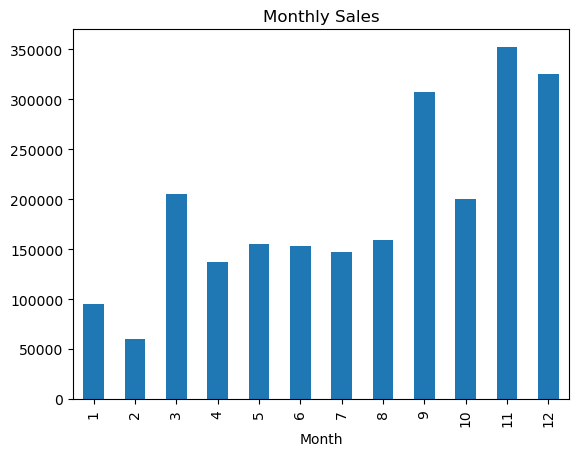

In [29]:
# Monthly Sales Pattern
df.groupby("Month")["Sales"].sum().plot(kind='bar')
plt.title("Monthly Sales")
plt.show()

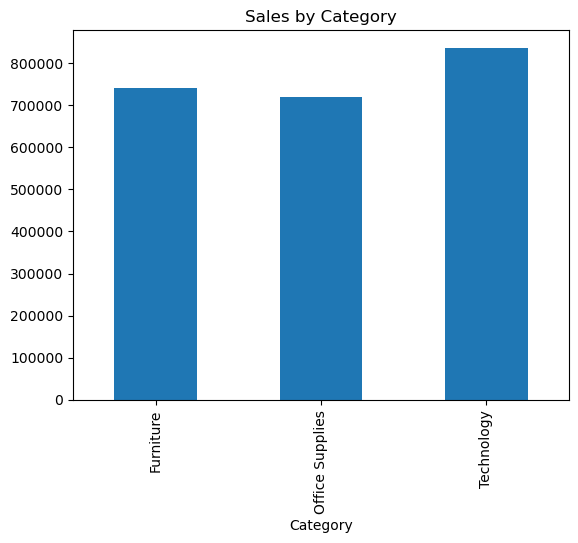

In [31]:
# Category Analysis
df.groupby("Category")["Sales"].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.show()

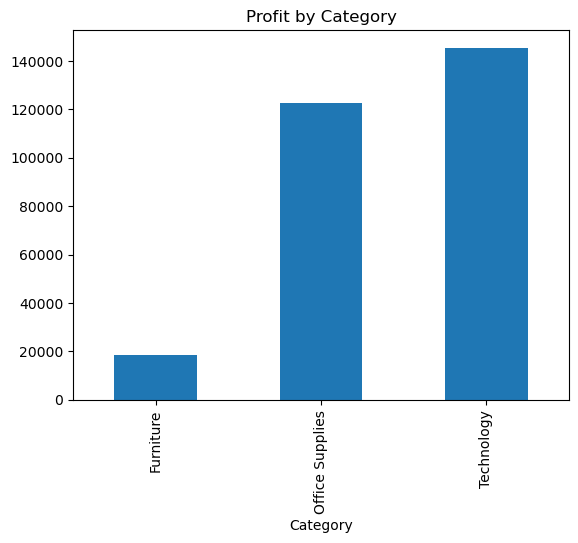

In [33]:
# Profit Analysis
df.groupby("Category")["Profit"].sum().plot(kind='bar')
plt.title("Profit by Category")
plt.show()

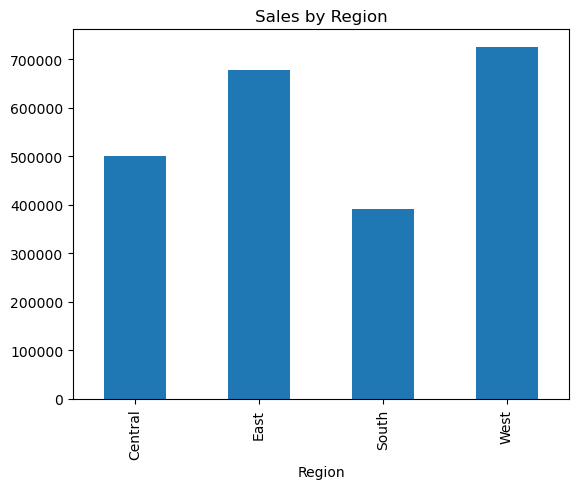

In [35]:
# Region Wise Sales
df.groupby("Region")["Sales"].sum().plot(kind='bar')
plt.title("Sales by Region")
plt.show()

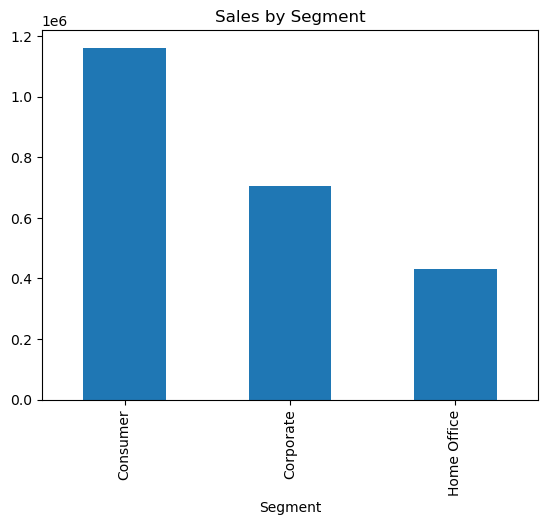

In [37]:
# Segment Analysis
df.groupby("Segment")["Sales"].sum().plot(kind='bar')
plt.title("Sales by Segment")
plt.show()

In [39]:
# Top Products
top_products = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
top_products.head(10)

Sub-Category
Phones         330007.0540
Chairs         328167.7310
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Name: Sales, dtype: float64

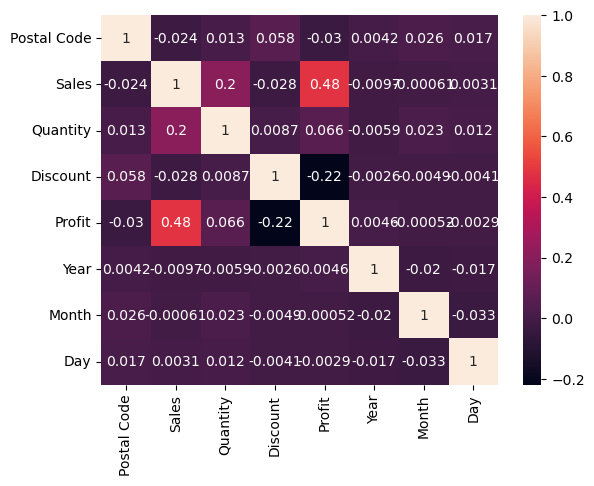

In [41]:
# Correlation
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [44]:
# installing prophet
!pip install prophet

In [58]:
import pandas as pd 
from prophet import Prophet
import matplotlib.pyplot as mltp

In [60]:
df = pd.read_csv("final_cleaned_data.csv")

In [64]:
# convert date column
df["Order Date"] = pd.to_datetime(df["Order Date"], format='mixed', dayfirst=True)

In [66]:
# prepare data for prophet- Aggreagate sales per day
df_forecast = df.groupby("Order Date")["Sales"].sum().reset_index()


In [68]:
# rename column for prophet
df_forecast = df_forecast.rename(columns={
    "Order Date": "ds",
    "Sales": "y"
})

In [76]:
# initialize model
model = Prophet()

In [78]:
# train model
model.fit(df_forecast)

21:57:04 - cmdstanpy - INFO - Chain [1] start processing
21:57:05 - cmdstanpy - INFO - Chain [1] done processing


In [80]:
# create future data
future = model.make_future_dataframe(periods=30)  # next 30 days

In [82]:
# predict
forecast=model.predict(future)

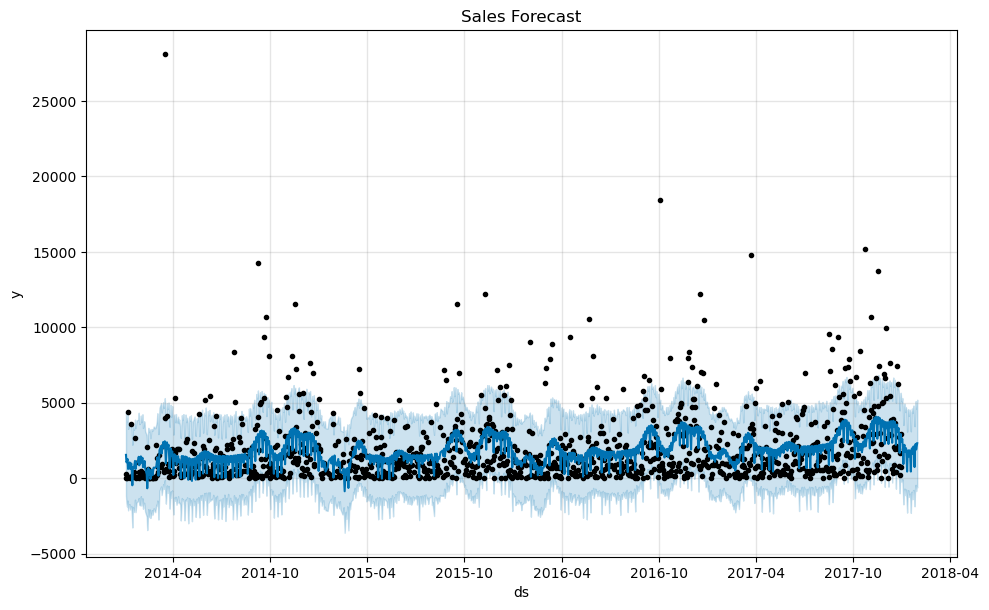

In [84]:
# plot forecast
model.plot(forecast)
plt.title("Sales Forecast")
plt.show()

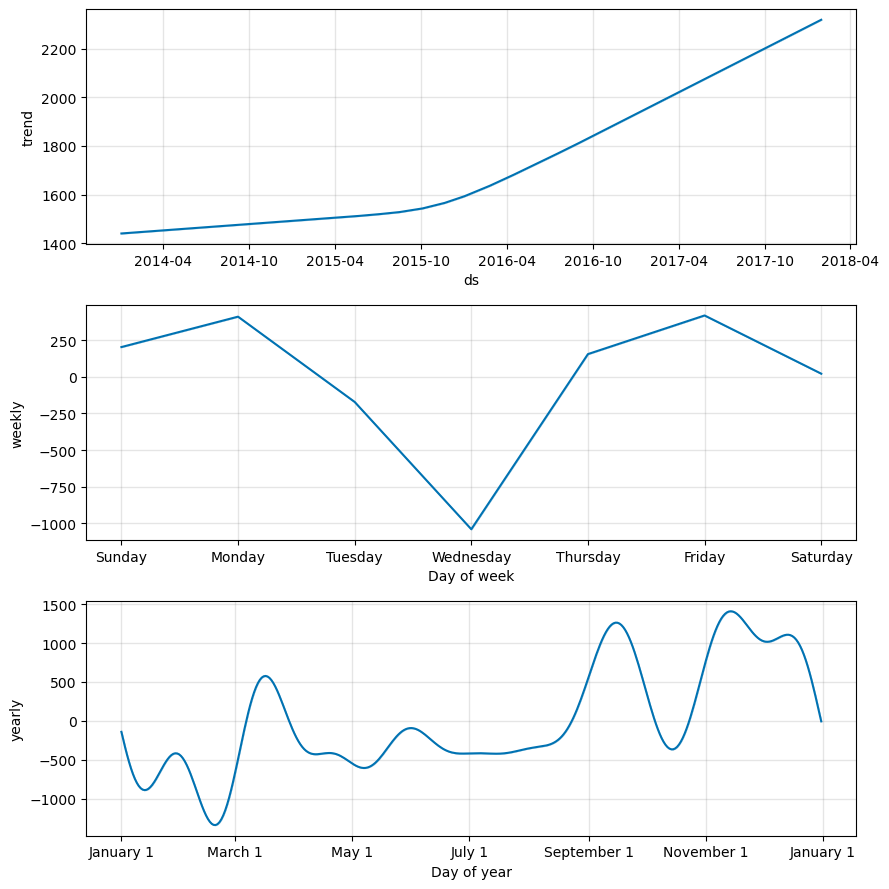

In [86]:
# plot components
model.plot_components(forecast)
plt.show()


In [88]:
# saving output successfully
forecast.to_csv("forecast_output.csv", index=False)

In [90]:
# this helps to show results
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
1262,2018-01-25,1966.450762,-689.139725,4462.346540
1263,2018-01-26,2263.701444,-447.438500,5098.032137
1264,2018-01-27,1892.560269,-861.870435,4610.854111
1265,2018-01-28,2093.318945,-550.715525,4910.345537
1266,2018-01-29,2311.600784,-620.499778,5192.635599
